# K-nearest neighbour algorithm 

KNNs tands for K-nearest neighbour, and it's one of the most popular and simplest classification and regrerssion clasifier used in machine learning today. KNN operatees on the assumption that similar data points are located near each other and can be grouped in the same category based on their proximity.

we load the three combined dataframes so we can use train for cross-validation / grid search and test as a final held-out evaluation. 
Next, we print shapes + columns to confirm everything looks as expected (the datasets should have the six sensor columns and a class column).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# reproducibility
RND = 42

train_df = pd.read_pickle('../pickles/combined/train_df.pkl')
valid_df = pd.read_pickle('../pickles/combined/valid_df.pkl')
test_df  = pd.read_pickle('../pickles/combined/test_df.pkl')

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test  shape:",  test_df.shape)
print("Columns:", train_df.columns.tolist())


Train shape: (23566, 7)
Valid shape: (8997, 7)
Test  shape: (5138, 7)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'class']


## Build feature matrix X and labels y, encode labels

This block is where we separate the features from the labels and make sure the labels are in a machine-friendly format (numeric).
The labels (y_train, y_valid, y_test) are strings like "walking", "running", "jumping". Many ML algorithms can’t work directly with text labels, they need numbers. LabelEncoder converts them: to 0, 1, 2, 3. We fit the encoder only on the training labels (so the mapping is learned there), and then apply the same mapping (transform) to valid and test labels.

In [2]:
feature_cols = [c for c in train_df.columns if c != 'class']

X_train = train_df[feature_cols].copy()
y_train = train_df['class'].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df['class'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['class'].copy()

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc  = le.transform(y_test)

print("Classes:", le.classes_)


Classes: ['jumping' 'running' 'stairs' 'walking']


## Choice of CV folds and k-range

We use 5-fold cross-validation. We have many samples, so 5 folds give a balance between stable estimate and compute time.

The K value in the KNN algorithm defines how many neighbors will be checked to determine the classification of a spcific query point. For k (number of neighbors), we search odd values from 1 to 25 (1,3,5,...,25). KNN can overfit with k=1 and oversmooth with large k, searching this odd range covers small-to-medium neighborhoods and avoids ties for even k when using majority voting.

For each candidate k, we run 5-fold cross-validation and calculate the average accuracy. At the end, the cross-validation tells us which k gives the best average accuracy.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

k_values = list(range(1, 26, 2))
param_grid = {'n_neighbors': k_values}

grid = GridSearchCV(knn,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1,
                    refit=True)

grid.fit(X_train, y_train_enc)

print("Best params:", grid.best_params_)
print("Best CV accuracy: {:.4f}".format(grid.best_score_))

Best params: {'n_neighbors': 5}
Best CV accuracy: 0.8800


## Plot CV accuracy as a function of k

This plot lets you visually inspect how sensitive model performance is to k and to the weights parameter. If accuracy is flat across a wide range of k, model is insensitive; if it changes rapidly, the model is sensitive and hyperparameter tuning matters.

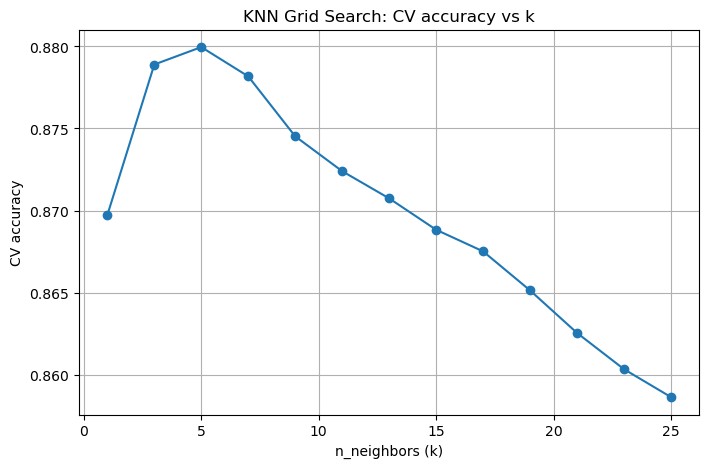

In [4]:
cv_results = pd.DataFrame(grid.cv_results_)

scores = cv_results[['param_n_neighbors', 'mean_test_score']]

# Plot accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(scores['param_n_neighbors'], scores['mean_test_score'], marker='o')
plt.xlabel('n_neighbors (k)')
plt.ylabel('CV accuracy')
plt.title('KNN Grid Search: CV accuracy vs k')
plt.grid(True)
plt.show()

## Evaluate the chosen model on the test set (final evaluation)

After hyperparameter selection, a final test evaluation gives an unbiased estimate of performance (since test set was not used in tuning).

In [5]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test)
y_test_pred_labels = le.inverse_transform(y_test_pred)
y_test_labels = y_test.values

test_acc = accuracy_score(y_test_enc, y_test_pred)
print("Test accuracy (KNN with best k): {:.4f}".format(test_acc))

print("\nClassification report (test):")
print(classification_report(y_test_labels, y_test_pred_labels, digits=4))


Test accuracy (KNN with best k): 0.9171

Classification report (test):
              precision    recall  f1-score   support

     jumping     0.8931    0.8833    0.8882      1088
     running     0.9142    0.8524    0.8822      1138
      stairs     0.9482    0.9451    0.9467      1841
     walking     0.8928    0.9720    0.9307      1071

    accuracy                         0.9171      5138
   macro avg     0.9121    0.9132    0.9119      5138
weighted avg     0.9175    0.9171    0.9167      5138



Difference between validation (CV) accuracy and test accuracy: the CV accuracy is the mean accuracy estimated by cross-validation on the training set. Test accuracy is measured on completely unseen data. If CV accuracy > test accuracy, suspect overfitting or distribution mismatch.

## Confusion Matrix

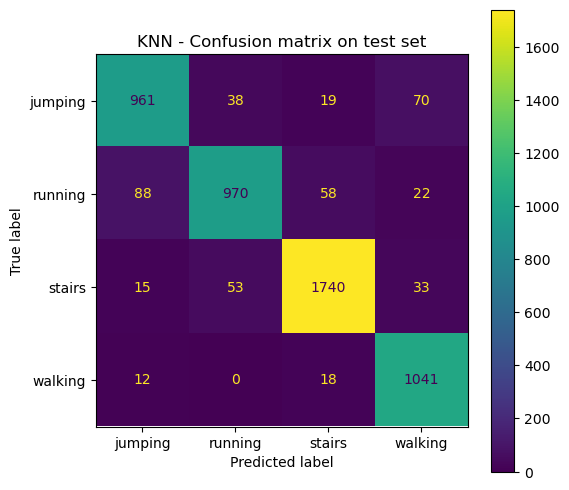

In [6]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test_labels, y_test_pred_labels),
                              display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, values_format='d')
plt.title('KNN - Confusion matrix on test set')
plt.show()


The confusion matrix shows that the KNN model performs very well overall, with most predictions lying on the diagonal (correct class). 'stairs' and 'walking' are classified with particularly high accuracy, with 1740 and 1041 correct predictions respectively and only a few misclassifications. However, 'jumping' and 'running' show more confusion: 'jumping' is sometimes predicted as 'walking' (70 cases), while 'running' is occasionally confused with both 'jumping' and 'stairs'. This suggests that the movements corresponding to 'jumping' and 'running' have more overlapping sensor patterns, making them harder for the model to distinguish.